In [3]:
pip install "numpy<2"

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.7/13.7 MB 4.2 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.3
    Uninstalling numpy-2.4.3:
      Successfully uninstalled numpy-2.4.3
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(img, title="", cmap="gray", size=(5,5)):
    plt.figure(figsize=size)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

Matplotlib is building the font cache; this may take a moment.


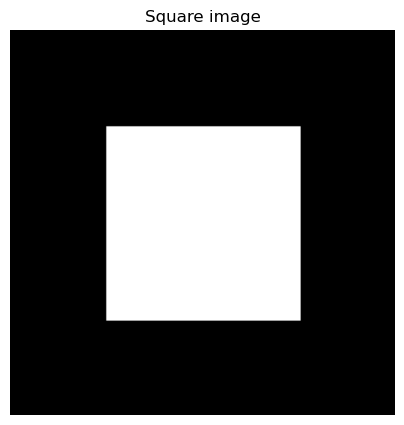

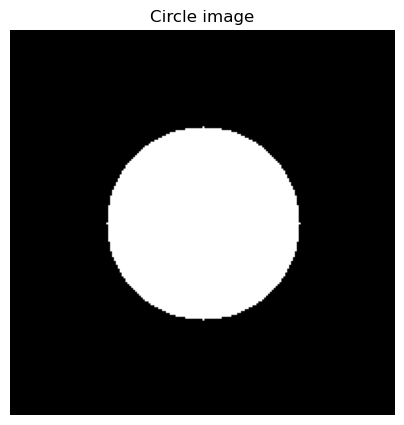

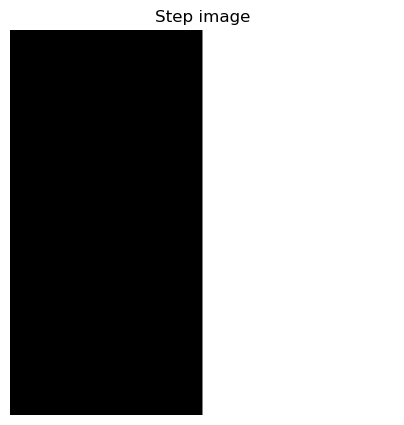

In [2]:
# Black background
img_square = np.zeros((200, 200), dtype=np.uint8)
img_circle = np.zeros((200, 200), dtype=np.uint8)
img_step = np.zeros((200, 200), dtype=np.uint8)

# Draw shapes
cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

# Create a step image: left side dark, right side bright
img_step[:, :100] = 50
img_step[:, 100:] = 220

show(img_square, "Square image")
show(img_circle, "Circle image")
show(img_step, "Step image")

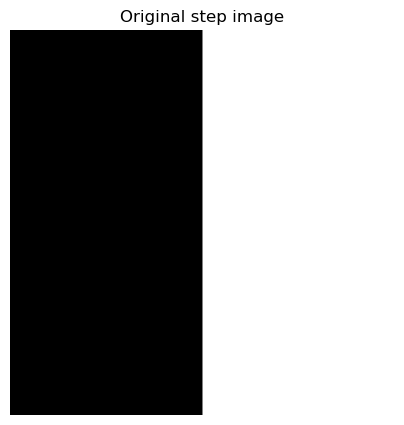

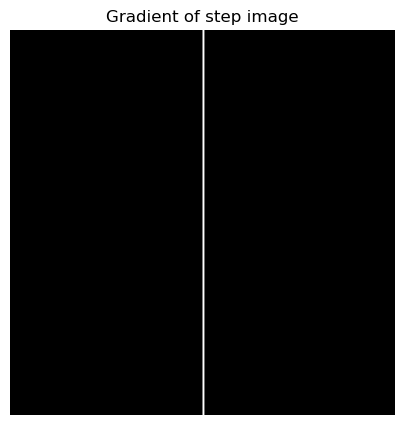

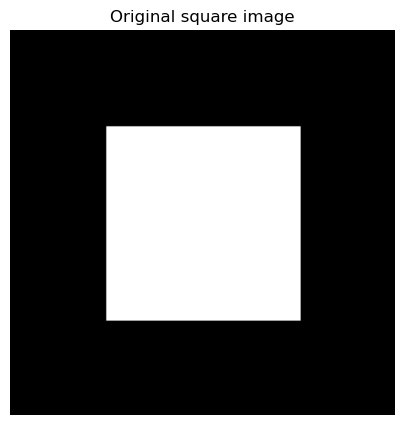

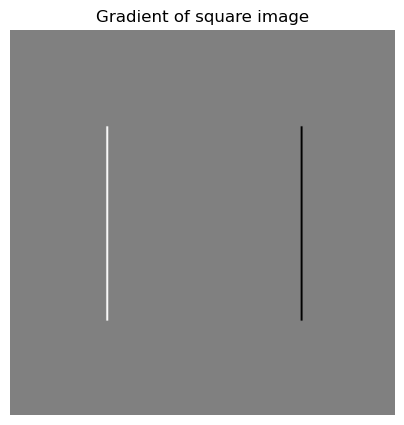

In [3]:
# Simple horizontal gradient kernel
kernel_x = np.array([[-1, 1]], dtype=np.float32)

grad_step = cv2.filter2D(img_step, cv2.CV_64F, kernel_x)
grad_square = cv2.filter2D(img_square, cv2.CV_64F, kernel_x)

show(img_step, "Original step image")
show(grad_step, "Gradient of step image")
show(img_square, "Original square image")
show(grad_square, "Gradient of square image")

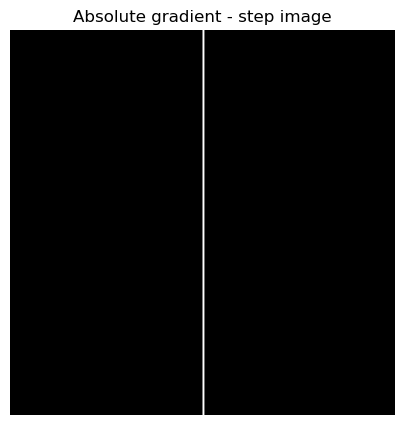

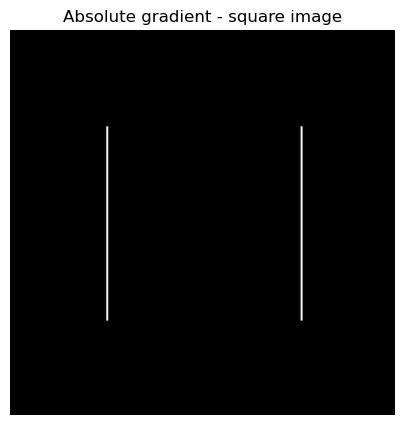

In [4]:
# Convert the gradient to absolute values for easier display
grad_square_abs = np.abs(grad_square).astype(np.uint8)
grad_step_abs = np.abs(grad_step).astype(np.uint8)

show(grad_step_abs, "Absolute gradient - step image")
show(grad_square_abs, "Absolute gradient - square image")

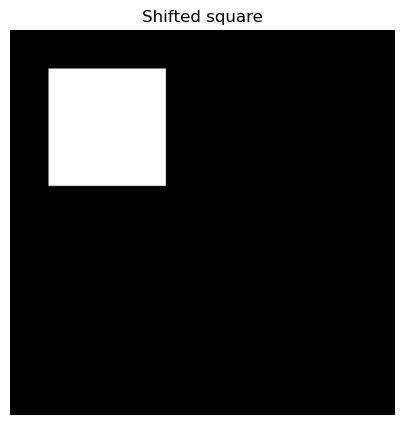

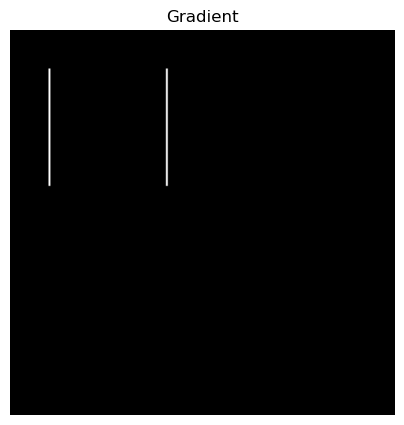

In [5]:
#task 1 - changing the square position

img_t1 = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(img_t1, (20, 20), (80, 80), 255, -1)  # moved to top-left
kernel_x = np.array([[-1, 1]], dtype=np.float32)
grad_t1 = cv2.filter2D(img_t1, cv2.CV_64F, kernel_x)

show(img_t1, "Shifted square")
show(np.abs(grad_t1).astype(np.uint8), "Gradient")

Dark (value=80) – max gradient: 80.0


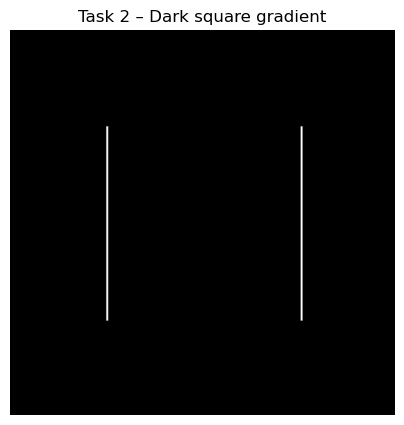

Medium (value=180) – max gradient: 180.0


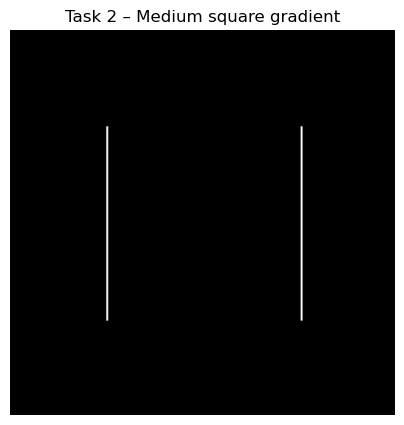

Bright (value=255) – max gradient: 255.0


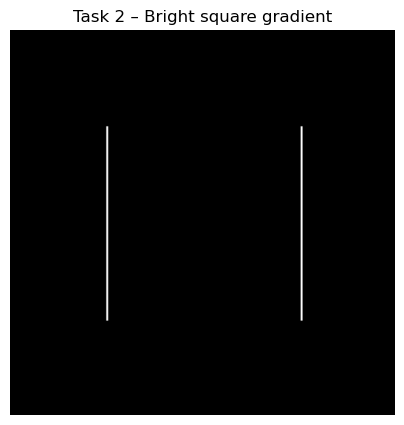

In [6]:
#task 2 - darker to brighter image


kernel_x = np.array([[-1, 1]], dtype=np.float32)

for brightness, label in [(80, "Dark"), (180, "Medium"), (255, "Bright")]:
    img = np.zeros((200, 200), dtype=np.uint8)
    cv2.rectangle(img, (50, 50), (150, 150), brightness, -1)
    grad = cv2.filter2D(img, cv2.CV_64F, kernel_x)
    print(f"{label} (value={brightness}) – max gradient: {np.abs(grad).max():.1f}")
    show(np.abs(grad).astype(np.uint8), f"Task 2 – {label} square gradient")

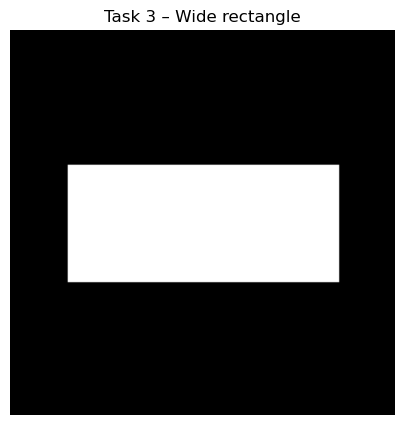

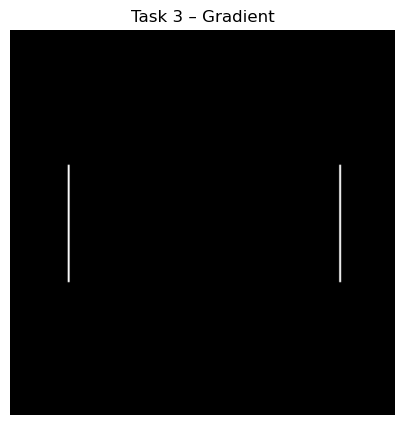

In [7]:
#task 3 - rectangle with different sizes

img_t3 = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(img_t3, (30, 70), (170, 130), 255, -1)  # wide, short rectangle

kernel_x = np.array([[-1, 1]], dtype=np.float32)
grad_t3 = cv2.filter2D(img_t3, cv2.CV_64F, kernel_x)

show(img_t3, "Wide rectangle")
show(np.abs(grad_t3).astype(np.uint8), "Gradient")

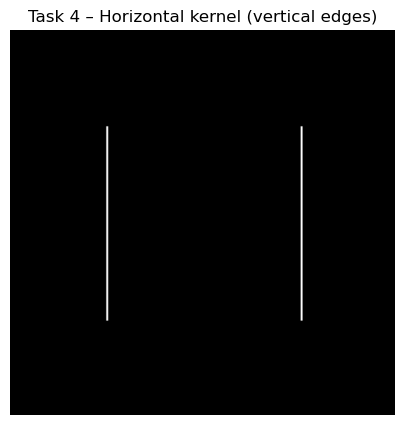

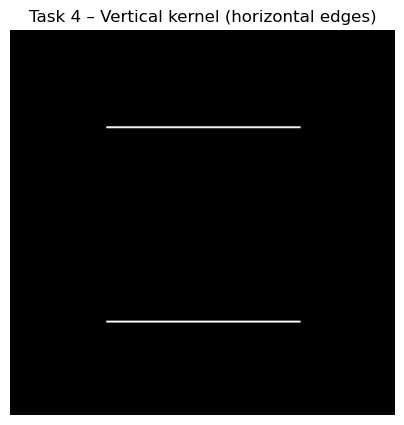

In [8]:
#intermediate task 

#vertical gradient kernel

img_square = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)

kernel_x = np.array([[-1, 1]], dtype=np.float32)
kernel_y = np.array([[-1], [1]], dtype=np.float32)

grad_x = cv2.filter2D(img_square, cv2.CV_64F, kernel_x)
grad_y = cv2.filter2D(img_square, cv2.CV_64F, kernel_y)

show(np.abs(grad_x).astype(np.uint8), "Task 4 – Horizontal kernel (vertical edges)")
show(np.abs(grad_y).astype(np.uint8), "Task 4 – Vertical kernel (horizontal edges)")

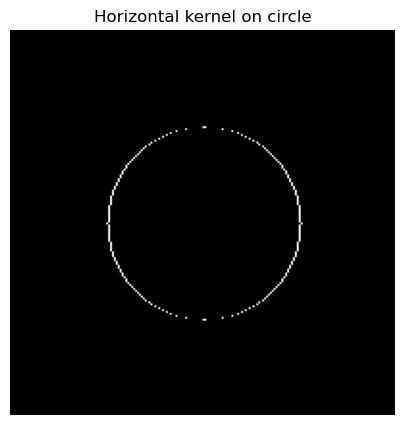

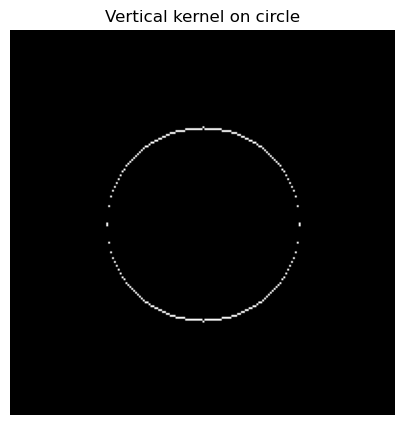

In [9]:
#task 5 - both vertical and horizontal kernel on the circle

img_circle = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

gx = cv2.filter2D(img_circle, cv2.CV_64F, kernel_x)
gy = cv2.filter2D(img_circle, cv2.CV_64F, kernel_y)

show(np.abs(gx).astype(np.uint8), "Horizontal kernel on circle")
show(np.abs(gy).astype(np.uint8), "Vertical kernel on circle")

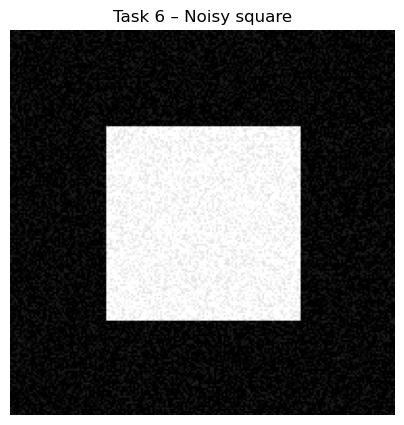

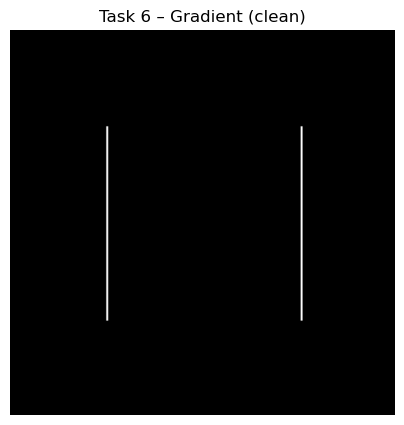

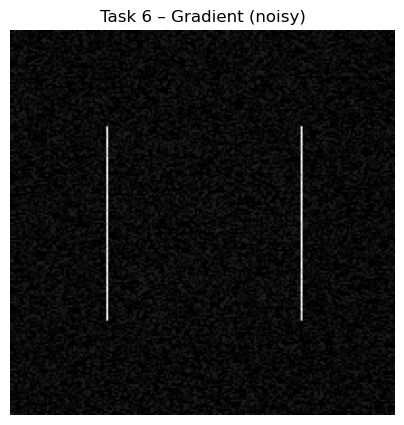

In [10]:
#task 6 - adding noise and testing stability

rng = np.random.default_rng(42)
noise = rng.integers(-30, 30, img_square.shape, dtype=np.int16)
img_noisy = np.clip(img_square.astype(np.int16) + noise, 0, 255).astype(np.uint8)

grad_clean = cv2.filter2D(img_square, cv2.CV_64F, kernel_x)
grad_noisy = cv2.filter2D(img_noisy,  cv2.CV_64F, kernel_x)

show(img_noisy, "Task 6 – Noisy square")
show(np.abs(grad_clean).astype(np.uint8), "Task 6 – Gradient (clean)")
show(np.abs(grad_noisy).astype(np.uint8), "Task 6 – Gradient (noisy)")

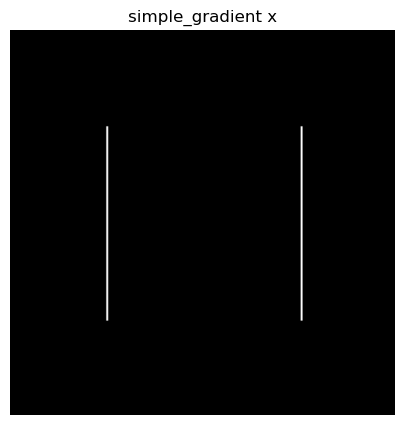

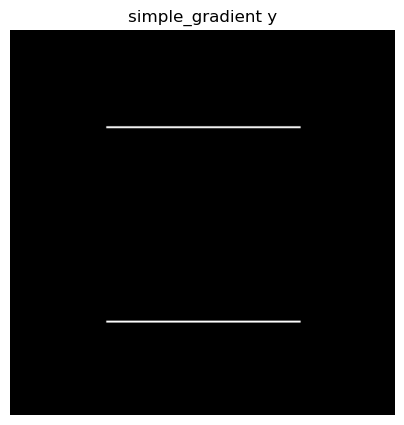

In [12]:
#challenging task 

#task 1 - simple_gradient function

def simple_gradient(image, direction='x'):   
    if direction == 'x':
        kernel = np.array([[-1, 1]], dtype=np.float32)
    elif direction == 'y':
        kernel = np.array([[-1], [1]], dtype=np.float32)
    else:
        raise ValueError("direction must be 'x' or 'y'")
    return cv2.filter2D(image, cv2.CV_64F, kernel)

# Test
show(np.abs(simple_gradient(img_square, 'x')).astype(np.uint8), "simple_gradient x")
show(np.abs(simple_gradient(img_square, 'y')).astype(np.uint8), "simple_gradient y")

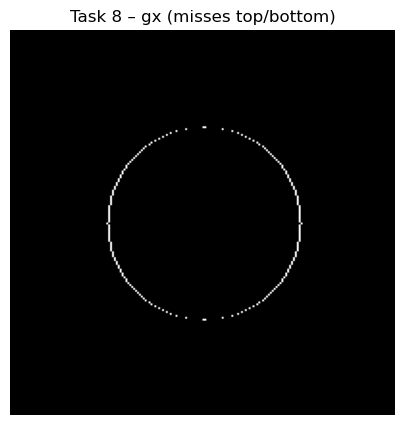

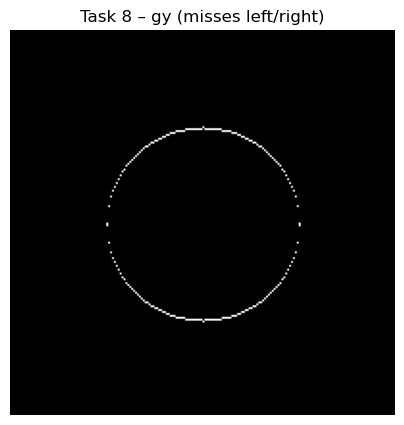

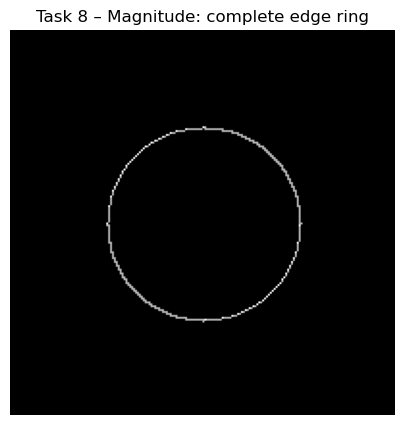

In [13]:
#combining x and y

img_circle = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

gx = simple_gradient(img_circle, 'x')
gy = simple_gradient(img_circle, 'y')
magnitude = np.sqrt(gx**2 + gy**2)

mag_display = (magnitude / magnitude.max() * 255).astype(np.uint8)

show(np.abs(gx).astype(np.uint8), "Task 8 – gx (misses top/bottom)")
show(np.abs(gy).astype(np.uint8), "Task 8 – gy (misses left/right)")
show(mag_display,                  "Task 8 – Magnitude: complete edge ring")

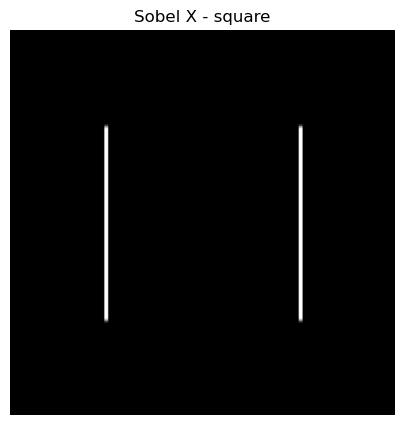

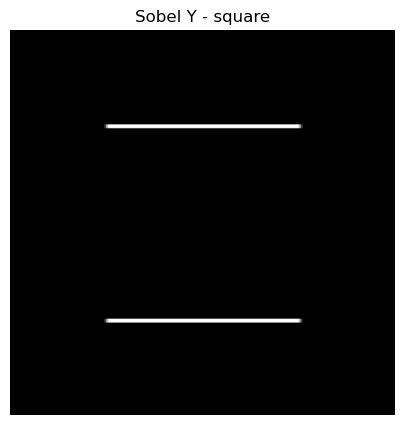

In [14]:
#TASK 2 - # Sobel in x and y directions
sobel_x = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_square, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_x), "Sobel X - square")
show(np.abs(sobel_y), "Sobel Y - square")


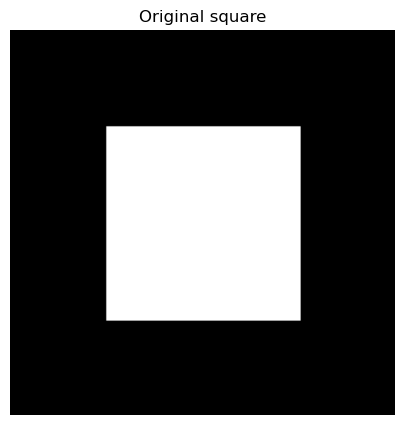

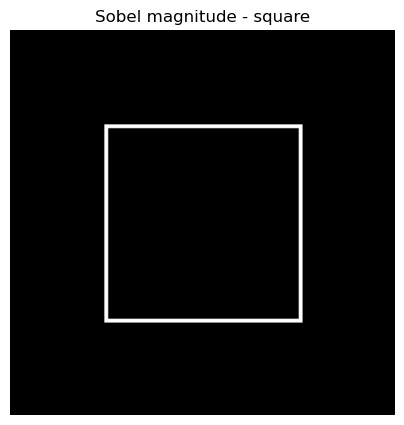

In [15]:
# Gradient magnitude from Sobel x and y
sobel_mag = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_mag = np.clip(sobel_mag, 0, 255).astype(np.uint8)

show(img_square, "Original square")
show(sobel_mag, "Sobel magnitude - square")

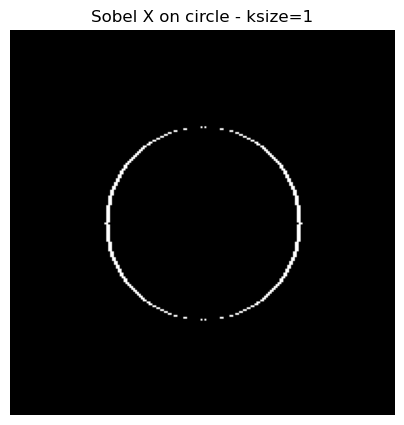

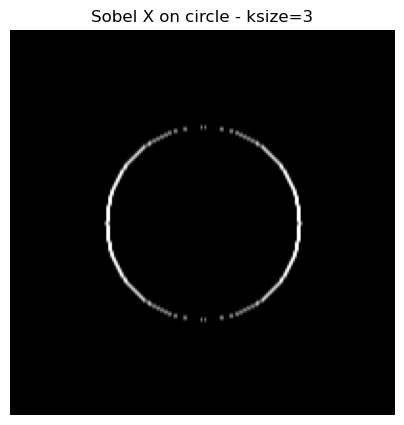

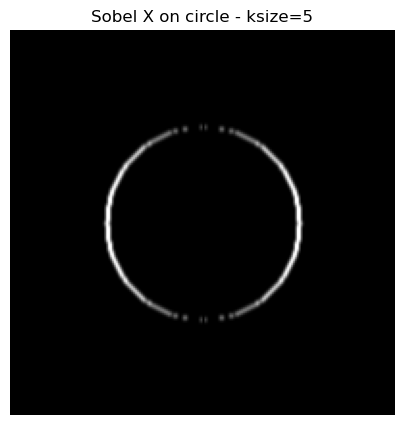

In [16]:
# Compare Sobel with different kernel sizes
for k in [1, 3, 5]:
    sobel_k = cv2.Sobel(img_circle, cv2.CV_64F, 1, 0, ksize=k)
    show(np.abs(sobel_k), f"Sobel X on circle - ksize={k}")

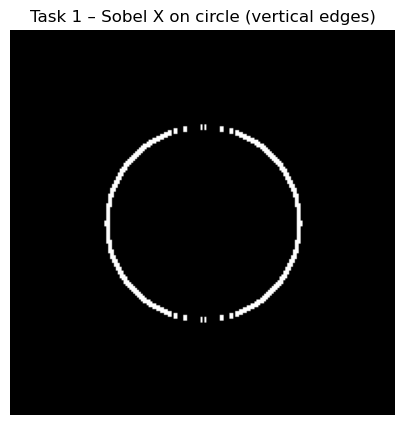

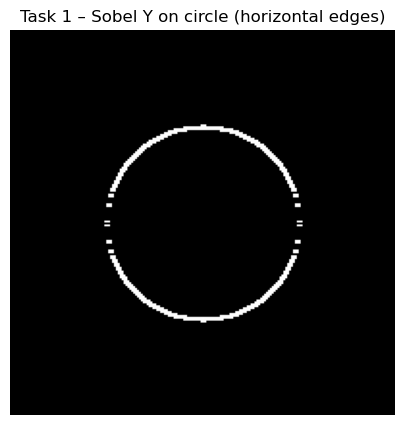

In [17]:
#topic 2 - task 1 - sobel x and y on the image

img_circle = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

sobel_x = cv2.Sobel(img_circle, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_circle, cv2.CV_64F, 0, 1, ksize=3)

show(np.abs(sobel_x).astype(np.uint8), "Sobel X on circle (vertical edges)")
show(np.abs(sobel_y).astype(np.uint8), "Sobel Y on circle (horizontal edges)")

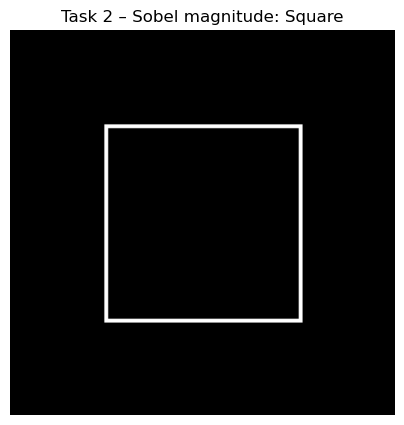

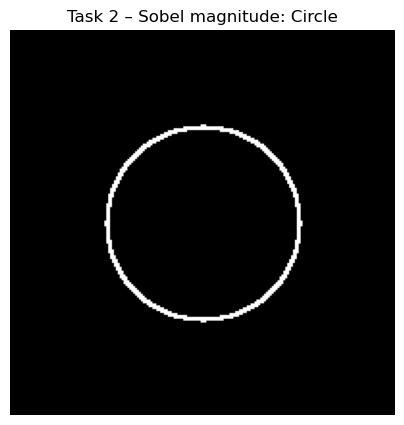

In [18]:
#task 2 - comparing sobel on square and circle

img_square = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)

for img, name in [(img_square, "Square"), (img_circle, "Circle")]:
    sx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    mag = np.sqrt(sx**2 + sy**2)
    mag = np.clip(mag, 0, 255).astype(np.uint8)
    show(mag, f"Sobel magnitude: {name}")

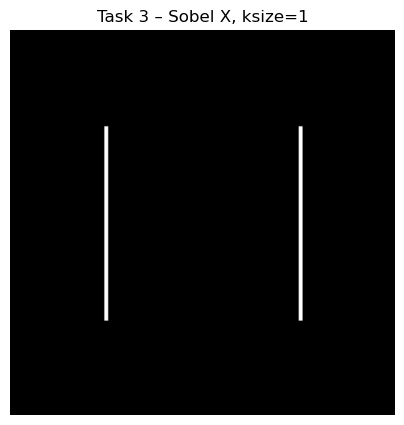

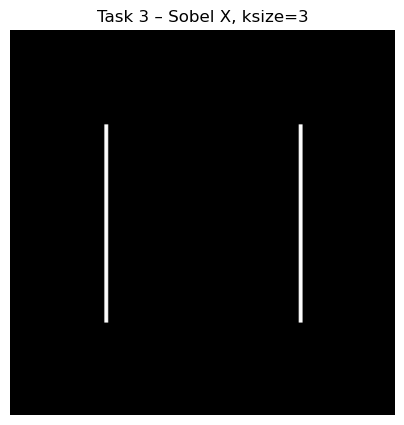

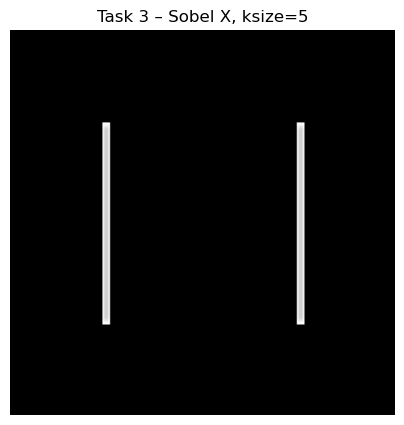

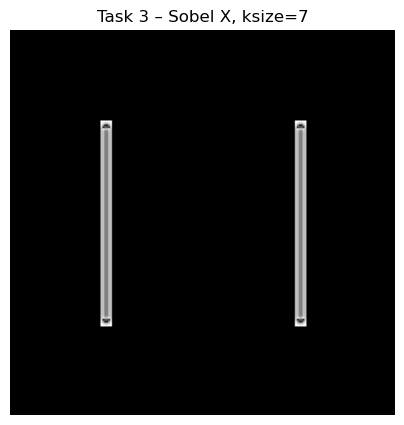

In [19]:
for k in [1, 3, 5, 7]:
    sx = cv2.Sobel(img_square, cv2.CV_64F, 1, 0, ksize=k)
    show(np.abs(sx).astype(np.uint8), f"Sobel X, ksize={k}")

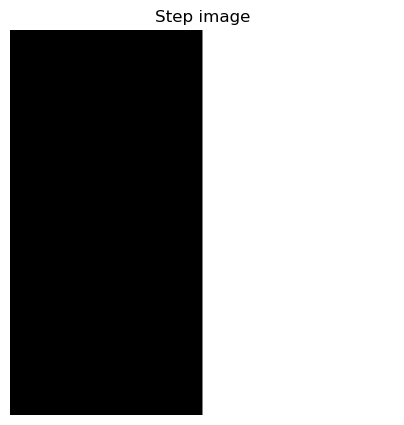

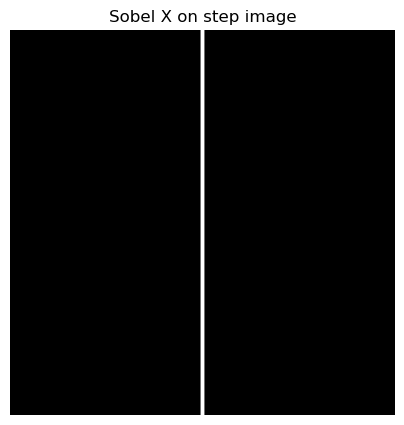

In [28]:
#INTERMEDIATE TASKS - task 3 - sobel on the step image

img_step = np.zeros((200, 200), dtype=np.uint8)
img_step[:, :100] = 50
img_step[:, 100:] = 220

sx_step = cv2.Sobel(img_step, cv2.CV_64F, 1, 0, ksize=3)
show(img_step, "Step image")
show(np.abs(sx_step).astype(np.uint8), "Sobel X on step image")

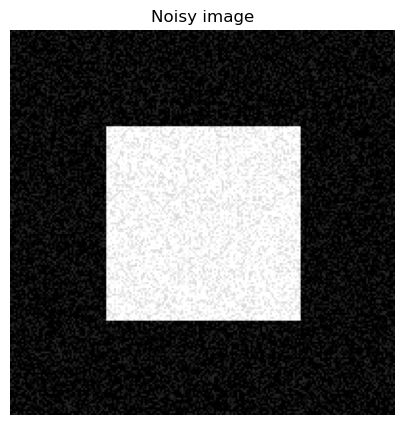

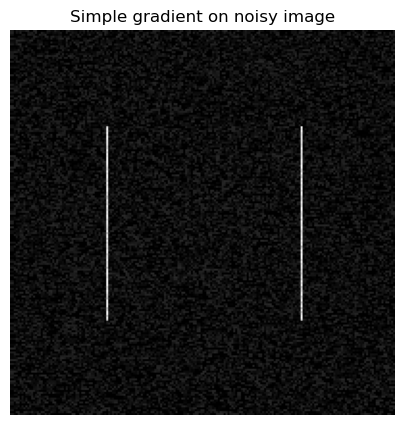

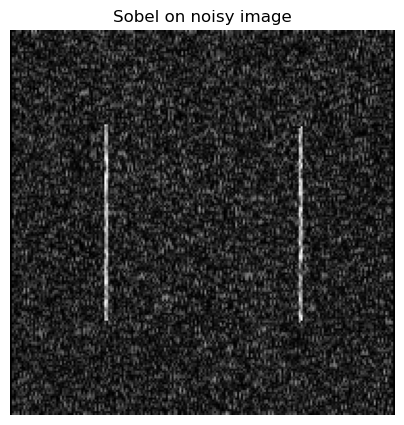

Simple gradient – mean response in flat region: 13.04
Sobel           – mean response in flat region: 34.03


In [21]:
#task 2 - 

# Add Gaussian noise
rng = np.random.default_rng(0)
noise = rng.integers(-40, 40, img_square.shape, dtype=np.int16)
img_noisy = np.clip(img_square.astype(np.int16) + noise, 0, 255).astype(np.uint8)

# Simple gradient 
kernel_x = np.array([[-1, 1]], dtype=np.float32)
grad_simple = cv2.filter2D(img_noisy, cv2.CV_64F, kernel_x)

# Sobel
grad_sobel = cv2.Sobel(img_noisy, cv2.CV_64F, 1, 0, ksize=3)

show(img_noisy,                              "Noisy image")
show(np.abs(grad_simple).astype(np.uint8),  "Simple gradient on noisy image")
show(np.abs(grad_sobel).astype(np.uint8),   "Sobel on noisy image")

# Quantify noise in flat regions
region_simple = np.abs(grad_simple[:40, :40])
region_sobel  = np.abs(grad_sobel[:40, :40])
print(f"Simple gradient – mean response in flat region: {region_simple.mean():.2f}")
print(f"Sobel           – mean response in flat region: {region_sobel.mean():.2f}")

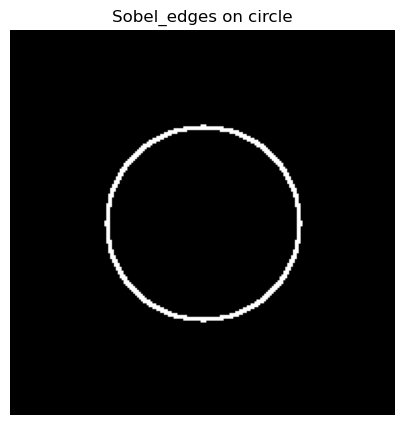

In [22]:
#challenging tasks - task 1 - creating a function

def sobel_edges(image, ksize=3):
    gx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=ksize)
    gy = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=ksize)
    magnitude = np.sqrt(gx**2 + gy**2)
    magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)
    return gx, gy, magnitude

# Quick test
gx, gy, mag = sobel_edges(img_circle)
show(mag, "Sobel_edges on circle")

Image        Max magnitude  Mean magnitude   Non-zero edge px
--------------------------------------------------------------
Square               255.0            5.15                808


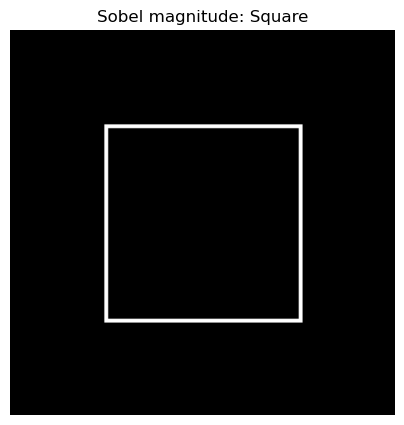

Circle               255.0            5.13                804


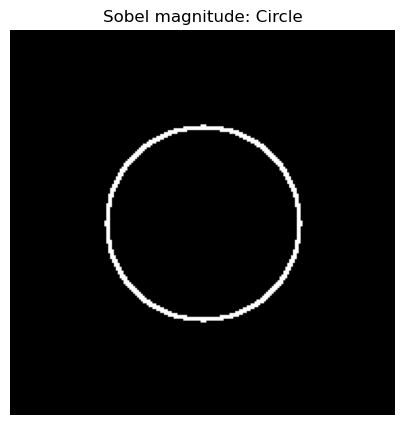

Step                 255.0            2.55                400


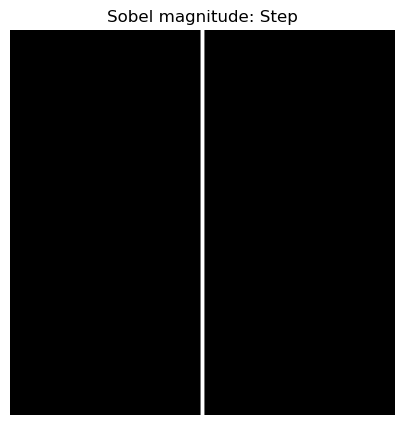

In [24]:
#Task 2 - applying function to three images and comparing

# Build three test images
img_square = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(img_square, (50, 50), (150, 150), 255, -1)

img_circle = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(img_circle, (100, 100), 50, 255, -1)

img_step = np.zeros((200, 200), dtype=np.uint8)
img_step[:, :100] = 50
img_step[:, 100:] = 220

images = {"Square": img_square, "Circle": img_circle, "Step": img_step}

print(f"{'Image':<10} {'Max magnitude':>15} {'Mean magnitude':>15} {'Non-zero edge px':>18}")
print("-" * 62)

for name, img in images.items():
    gx, gy, mag = sobel_edges(img, ksize=3)
    nonzero = np.count_nonzero(mag > 10)
    print(f"{name:<10} {mag.max():>15.1f} {mag.mean():>15.2f} {nonzero:>18}")
    show(mag, f"Sobel magnitude: {name}")

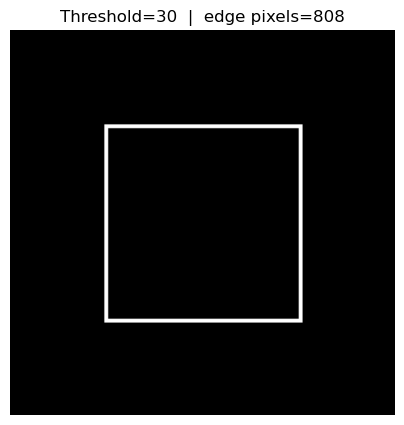

Threshold  30: 808 edge pixels retained


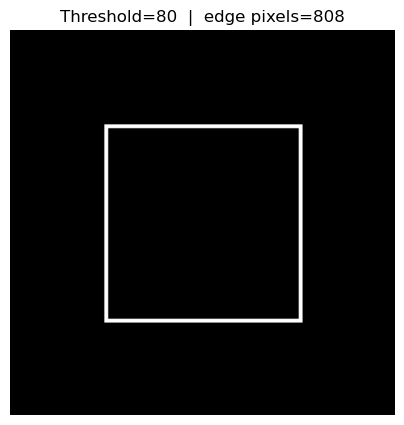

Threshold  80: 808 edge pixels retained


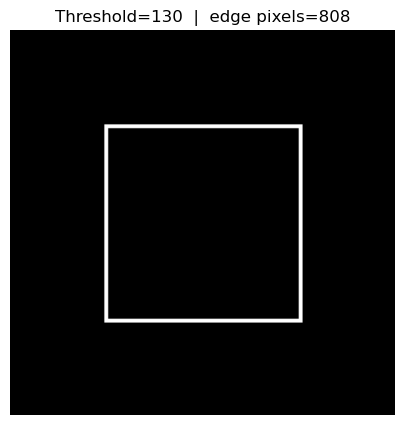

Threshold 130: 808 edge pixels retained


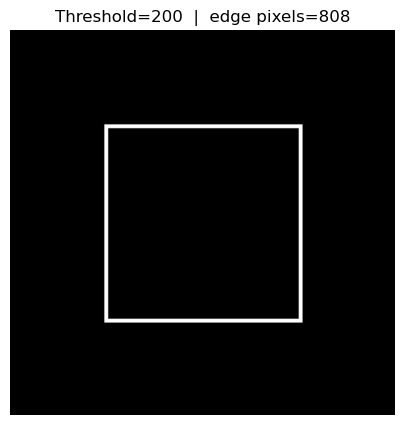

Threshold 200: 808 edge pixels retained


In [26]:
_, _, sobel_mag = sobel_edges(img_square, ksize=3)

thresholds = [30, 80, 130, 200]

for t in thresholds:
    binary = (sobel_mag > t).astype(np.uint8) * 255
    edge_px = np.count_nonzero(binary)
    show(binary, f"Threshold={t}  |  edge pixels={edge_px}")
    print(f"Threshold {t:>3}: {edge_px} edge pixels retained")